# Small crystalline dataset

> Georgios Varnavides | Oct 21 2025  
>
> Sample: thin strontium titanate (STO)  
> Sampling conditions: Nyquist  
> Imaging conditions: 20 mrad, in-focus, defocus, coma, defocus + coma  

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import ipywidgets

import ase
import abtem
from pathlib import Path
import ase.build
import abtem
from ase.cluster import FaceCenteredCubic

# abtem.config.set({'dask.lazy': False})

## STO Unitcell

We'll make an ASE Atoms object using Materials Project entry [mp-5229](https://next-gen.materialsproject.org/materials/mp-5229). Note this uses Wyckoff Positions and Spacegroups, but you can also export the CIF/POSCAR file if you prefer.

## new potential

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='y [Å]'>)

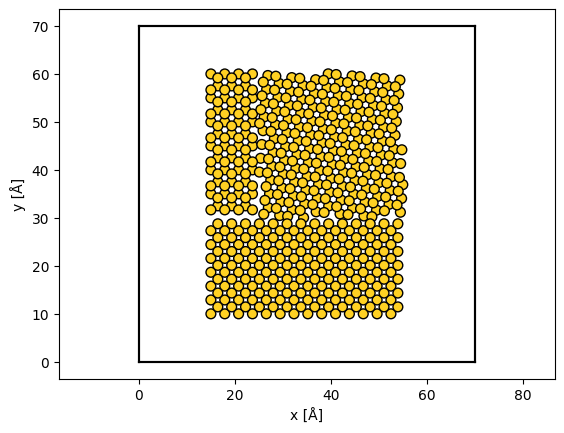

In [3]:
from ase.build import fcc111, fcc100
lc=4.08
unit_cell = fcc111('Au', size=(2, 2, 2), a=lc, vacuum=0.1, orthogonal=False)
unit_cell_3 = fcc100('Au', size=(2, 2, 2), a=lc, vacuum=0.00001)
nanoparticle_1 = abtem.orthogonalize_cell(unit_cell) * (16,8,1)
nanoparticle_2 = abtem.orthogonalize_cell(unit_cell) * (16,8,1)
nanoparticle_3 = abtem.orthogonalize_cell(unit_cell_3) * (16,8,1)
nanoparticle_2.rotate(25,'z')
# Get positions for each nanoparticle
pos1 = nanoparticle_1.get_positions()
pos2 = nanoparticle_2.get_positions()
pos3 = nanoparticle_3.get_positions()

# Create boolean masks based on x, y conditions
mask1 = (pos1[:, 0] < 10) & (pos1[:, 1] > 20) & (pos1[:, 1] <50)  # x < 10 AND y < 15
mask2 = (pos2[:, 0] > 10) & (pos2[:, 1] > 20) & (pos2[:, 1] <50) & (pos2[:,0] <40) # x > 10 AND y > 15
mask3 = (pos3[:, 1] < 20) & (pos3[:,0] <40)

# Apply masks using index arrays
filtered_1 = nanoparticle_1[np.where(mask1)[0]]
filtered_2 = nanoparticle_2[np.where(mask2)[0]]
filtered_3 = nanoparticle_3[np.where(mask3)[0]]

# Combine the two filtered structures
supported_nanoparticle = filtered_1 + filtered_2 + filtered_3
supported_nanoparticle.center(vacuum=10)
x_length = supported_nanoparticle.cell[0, 0]
y_length = supported_nanoparticle.cell[1, 1]
max_length = max(x_length, y_length)

if x_length < max_length:
    extra_vacuum = (max_length - x_length) / 2
    supported_nanoparticle.center(axis=0, vacuum=10 + extra_vacuum)

if y_length < max_length:
    extra_vacuum = (max_length - y_length) / 2
    supported_nanoparticle.center(axis=1, vacuum=10 + extra_vacuum)
# supported_nanoparticle.center(axis=1, vacuum=0)
# supported_nanoparticle.center(axis=0, vacuum=0)
# print(x_length, y_length)
# mask = supported_nanoparticle.positions[:, 1] >40
# del supported_nanoparticle[np.where(mask)[0]]
# supported_nanoparticle.center(axis=1, vacuum=0)

abtem.show_atoms(supported_nanoparticle)

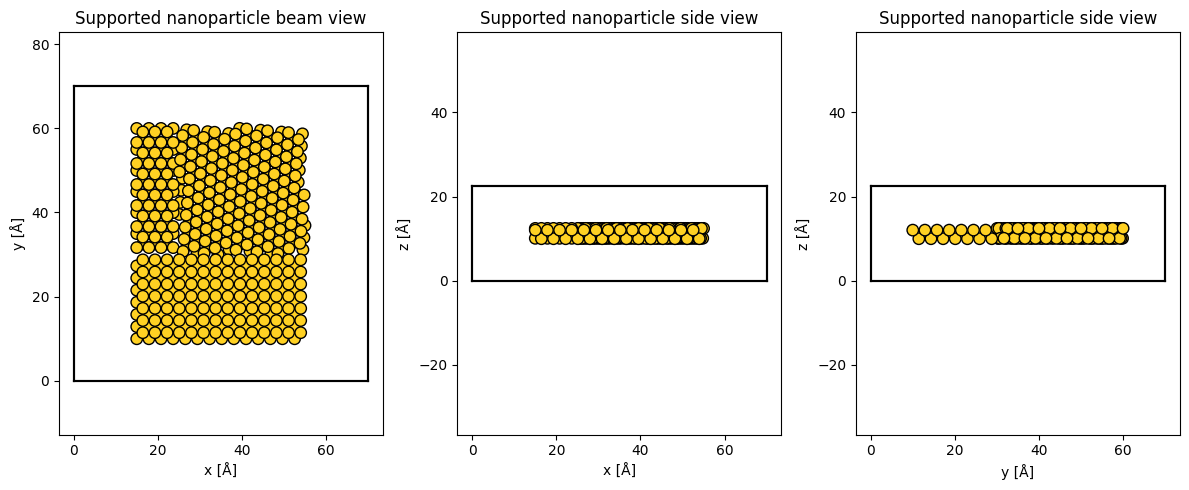

In [4]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
abtem.show_atoms(
    supported_nanoparticle,
    ax=ax1,
    title="Supported nanoparticle beam view",
    merge=0.5,
    scale=1,
)
abtem.show_atoms(
    supported_nanoparticle,
    ax=ax2,
    plane="xz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.5,
)
abtem.show_atoms(
    supported_nanoparticle,
    ax=ax3,
    plane="yz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.5,
)
fig.tight_layout();

## Potential 

We build the numeric representation of the atomic potentials.

In [5]:
potential = abtem.Potential(
    supported_nanoparticle,
    sampling=4/64,
    slice_thickness= 2/4,
).build(
    lazy=False
)

x_min = 0
x_max = 43
y_min = 0
y_max = 43
gpts_xy = (48, 48)


In [6]:
len(potential.array)

45

## Probe

We use a converged probe with a few different aberrations.

In [7]:
energy = 20e3 # eV
semiangle_cutoff = 20 # mrad
defocus =00
astig =  0000
astig_angle = -0.8
spherical = 000000
aberrations = {
    "C10":defocus,
    "C21":astig,
    "phi21":astig_angle,
    "C30":spherical,
}

# 2x2 probes ensemble
probes = abtem.Probe(
    energy=energy,
    semiangle_cutoff=semiangle_cutoff,
    aberrations=aberrations,
    # device='gpu',
).match_grid(
    potential
)

# probes.show(
#     explode=True
# )

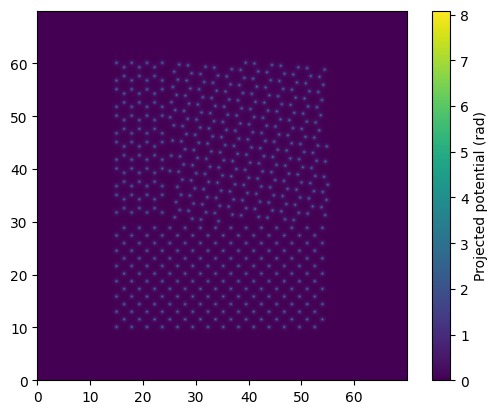

In [8]:
fig, ax = plt.subplots()
im = ax.imshow(potential.project().array.T * abtem.core.energy.energy2sigma(energy),extent=[0, potential.extent[0], 0, potential.extent[1]],origin='lower')
fig.colorbar(im, ax=ax, label='Projected potential (rad)')

## Simulations

In [11]:
grid_scan_Nyquist = abtem.GridScan(
    start = (0, 0),
    end = (potential.extent[0], potential.extent[1]),
    gpts=gpts_xy
)

# grid_scan_Nyquist = abtem.GridScan(
#     start = (0, 0),
#     end = (40,40),
#     gpts=gpts_xy
# )

detector = abtem.PixelatedDetector(
    max_angle=None
)

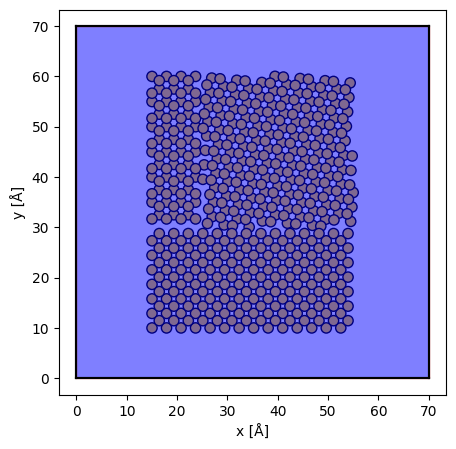

In [13]:
#| label: app:detectors_scansa
fig,ax = plt.subplots(figsize=(5,5))
abtem.show_atoms(
    supported_nanoparticle,
    ax=ax
)
grid_scan_Nyquist.add_to_plot(ax,alpha=0.5,facecolor='b')


In [14]:
measurements = probes.scan(
    potential,
    grid_scan_Nyquist,
    detector
)
print(measurements)
measurements= measurements.compute(
)
    
measurements_cropped = measurements.crop(
     gpts=(192,192)
)


tasks:   0%|          | 0/194 [00:00<?, ?it/s]

## Save Multidimensional Dataset
Temporary fix, until abTEM supports zarr>3.

In [15]:
import quantem as em

sampling = [
    grid_scan_Nyquist.sampling[0],
    grid_scan_Nyquist.sampling[1],
    measurements_cropped.angular_sampling[0],
    measurements_cropped.angular_sampling[1],
]

units = ["A","A","mrad","mrad"]

dataset_cropped = em.core.datastructures.Dataset.from_array(
    measurements_cropped.to_cpu().array,
    sampling=sampling,
    units=units,
)

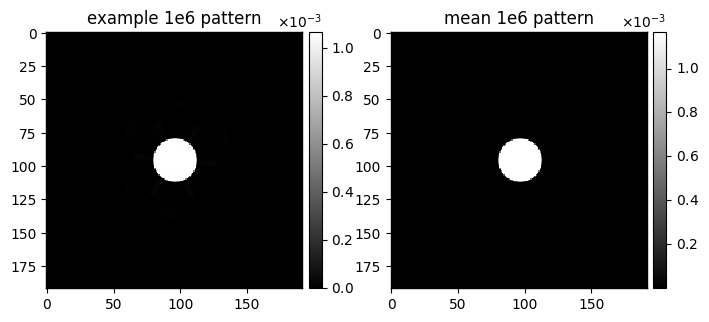

In [16]:


em.visualization.show_2d(
    [
        dataset_cropped[30,30].array,
        dataset_cropped.mean((0,1)),
    ],
    title=[
        "example 1e6 pattern","mean 1e6 pattern"
    ],
    cbar=True,
    show_ticks=True
);


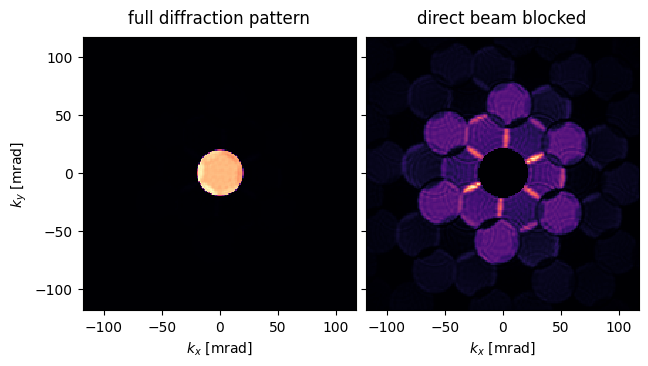

In [18]:
abtem.stack(
    [
        measurements_cropped[28,29],
        measurements_cropped[28,29].block_direct(radius=20)
    ],
    ("full diffraction pattern","direct beam blocked")
).show(
    explode=True,
    units="mrad",
    cmap='magma'
);

probe_wave.array shape: (1120, 1120)


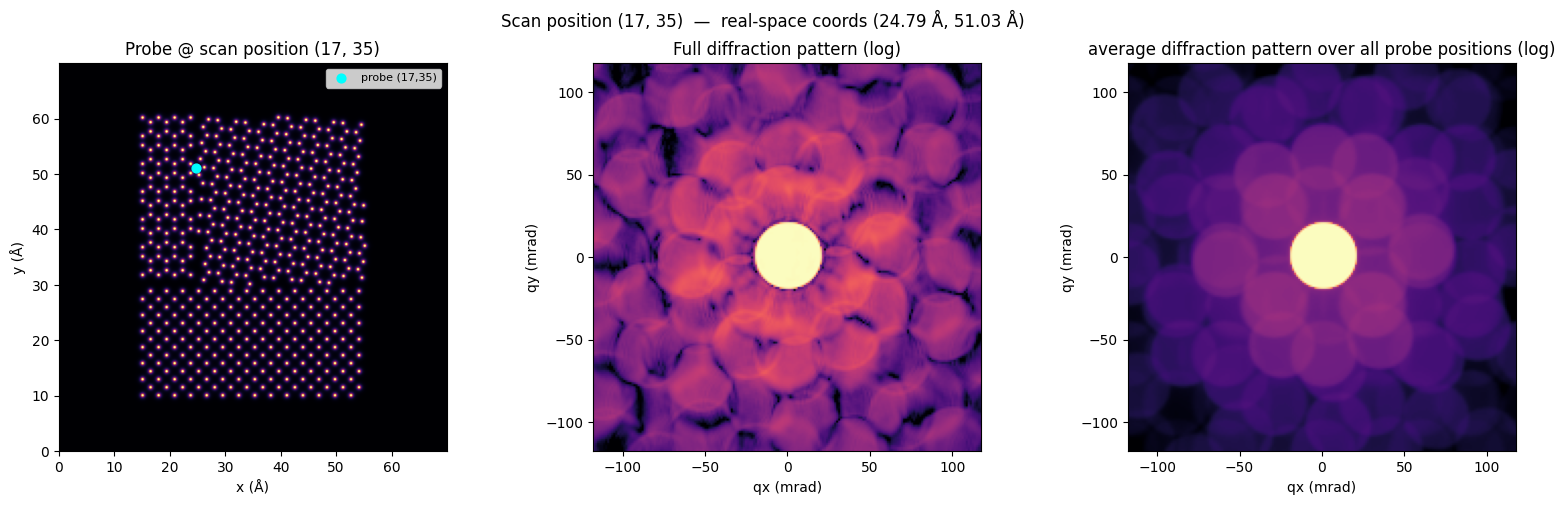

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# ─── INPUT ───────────────────────────────────────────────────────────────────
scan_x, scan_y = 17, 35   # <── change these
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── 1. Potential projected (sum over slices) ──────────────────────────────────
pot_array = potential.array
if hasattr(pot_array, 'compute'):
    pot_array = pot_array.compute()
pot_array = np.array(pot_array).sum(axis=0)   # sum slices → 2-D

pot_extent = [0, potential.extent[0], 0, potential.extent[1]]

# Clip top 1% to avoid hot pixels washing out contrast
vmin = np.percentile(pot_array, 1)
vmax = np.percentile(pot_array, 99)

axes[0].imshow(
pot_array.T, origin="lower", extent=pot_extent, cmap="inferno", vmin=vmin, vmax=vmax
)

# ── 2. Probe real-space intensity overlaid ────────────────────────────────────
probe_wave = probes.build()
probe_arr = np.array(probe_wave.array)
print("probe_wave.array shape:", probe_arr.shape)   # debug — remove once working

# Squeeze out any leading batch/ensemble dims → want shape (Ny, Nx)
while probe_arr.ndim > 2:
    probe_arr = probe_arr[0]

probe_intensity = np.abs(probe_arr)**2

# Physical extent of the probe array
probe_extent_phys = probes.extent   # (Lx, Ly) in Å

# Scanning step size
dx = potential.extent[0] / gpts_xy[0]
dy = potential.extent[1] / gpts_xy[1]

# Centre of the chosen scan pixel in Å
cx = scan_x * dx
cy = scan_y * dy

probe_shifted_extent = [
    cx - probe_extent_phys[0] / 2,
    cx + probe_extent_phys[0] / 2,
    cy - probe_extent_phys[1] / 2,
    cy + probe_extent_phys[1] / 2,
]

axes[0].imshow(
    probe_intensity.T,
    origin="lower",
    extent=probe_shifted_extent,
    cmap="hot",
    alpha=0.0,
    vmin=0,
    vmax=probe_intensity.max() * 0.8,
)

axes[0].scatter([cx], [cy], color="cyan", s=40, zorder=5, label=f"probe ({scan_x},{scan_y})")
axes[0].set_xlim(pot_extent[0], pot_extent[1])
axes[0].set_ylim(pot_extent[2], pot_extent[3])
axes[0].set_xlabel("x (Å)")
axes[0].set_ylabel("y (Å)")
axes[0].set_title(f"Probe @ scan position ({scan_x}, {scan_y})")
axes[0].legend(fontsize=8)

# ── 3 & 4. Diffraction patterns ───────────────────────────────────────────────
dp_arr = np.array(dataset_cropped.array[scan_x, scan_y])
dp_arr_blocked = np.array(dataset_cropped.array).mean(axis=(0, 1))

# manually mask direct beam for second plot
cy_dp, cx_dp = dp_arr.shape[0]//2, dp_arr.shape[1]//2
Y, X = np.ogrid[:dp_arr.shape[0], :dp_arr.shape[1]]
r_pix = int(20 / measurements_cropped.angular_sampling[0])
mask = (X - cx_dp)**2 + (Y - cy_dp)**2 <= r_pix**2
# dp_arr_blocked[mask] = np.nan

for ax, arr, title in zip(
    axes[1:],
    [dp_arr, dp_arr_blocked],
    ["Full diffraction pattern", "average diffraction pattern over all probe positions"],
):
    log_arr = np.log10(arr + 1e-10)
    log_arr[arr == 0] = np.nan
    vmin_dp = np.nanpercentile(log_arr, 1)
    vmax_dp = np.nanpercentile(log_arr, 99)

    sx = measurements_cropped.angular_sampling[0]
    sy = measurements_cropped.angular_sampling[1]
    nx, ny = arr.shape
    dp_extent = [-sx*nx/2, sx*nx/2, -sy*ny/2, sy*ny/2]

    ax.imshow(
        log_arr,
        origin="lower",
        cmap="magma",
        extent=dp_extent,
        vmin=vmin_dp,
        vmax=vmax_dp,
    )
    ax.set_xlabel("qx (mrad)")
    ax.set_ylabel("qy (mrad)")
    ax.set_title(title + " (log)")

plt.suptitle(
    f"Scan position ({scan_x}, {scan_y})  —  "
    f"real-space coords ({cx:.2f} Å, {cy:.2f} Å)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

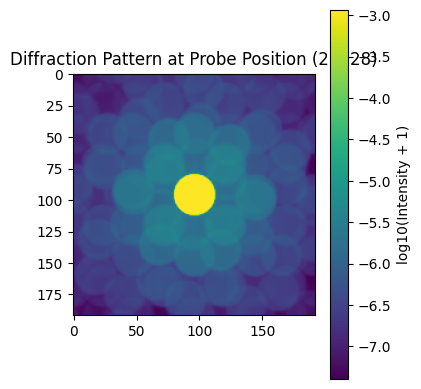

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
im = ax.imshow(np.log10(measurements_cropped.mean(axis=(0,1)).array + 1e-10), cmap='viridis')
ax.set_title('Diffraction Pattern at Probe Position (28, 28)')
plt.colorbar(im, ax=ax, label='log10(Intensity + 1)')
plt.tight_layout()
plt.show()

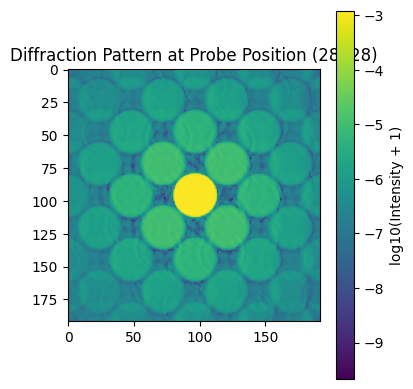

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
im = ax.imshow(np.log10(measurements_cropped[32,15].array + 1e-10), cmap='viridis')
ax.set_title('Diffraction Pattern at Probe Position (28, 28)')
plt.colorbar(im, ax=ax, label='log10(Intensity + 1)')
plt.tight_layout()
plt.show()

## Start Reconstruction

In [22]:
import quantem as em
import numpy as np

In [23]:
energy = 20e3 # eV
semiangle_cutoff = 20 # mrad
defocus = 0
astig =  0000
astig_angle = -0.8
spherical = 000000
aberrations = {
    "C10":defocus,
    "C21":astig,
    "phi21":astig_angle,
    "C30":spherical,
}
semiangle_cutoff = 20  # mrad
gpts_xy = (48, 48)  # number of probe positions in x and y

In [24]:
aberrations_flat = [aberrations]
aberrations_flat

[{'C10': 0, 'C21': 0, 'phi21': -0.8, 'C30': 0}]

In [25]:
def add_poisson_noise(
    dataset,
    electrons_per_area,
):
    if electrons_per_area == np.inf:
        return dataset
    electrons_per_probe = electrons_per_area * dataset.sampling[:2].prod()
    
    dataset_noisy = dataset.copy()
    dataset_noisy.array = np.random.poisson(dataset.array * electrons_per_probe)
    return dataset_noisy

Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to 0.


Normalizing intensities:   0%|          | 0/2304 [00:00<?, ?probe position/s]

[1.22710103 1.22710103]


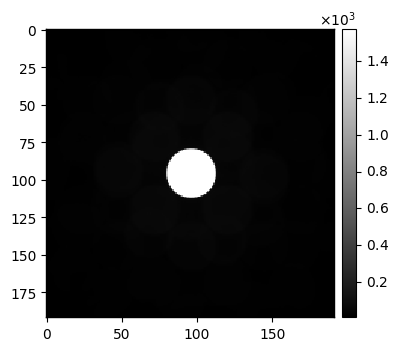

In [26]:
np.random.seed(2025)
noisy_dataset_cropped = add_poisson_noise(
            dataset_cropped,
            10e8
        )

direct_ptychography_classes = [
        em.diffractive_imaging.DirectPtychography.from_dataset4d(
            noisy_dataset_cropped,
            energy=energy,
            semiangle_cutoff=semiangle_cutoff,
            rotation_angle=0,
            aberration_coefs=aberrations_flat[0],
            # device='gpu',
        )
]
        
pdset = em.diffractive_imaging.PtychographyDatasetRaster.from_dataset4dstem(
    noisy_dataset_cropped
)

pdset.preprocess(
    force_com_rotation=0,
    force_com_transpose=0,
    plot_com=False,
    probe_energy=energy,
)


em.visualization.show_2d(
    np.tile(
        pdset.targets.mean(dim=0),
        (1,1)
    ),
    cbar=True,
    show_ticks=True
)
print(pdset.detector_sampling)

In [27]:
iterative_ptycho = em.diffractive_imaging.PtychoLite.from_dataset(
    dset=pdset,
    num_slices=1,
    num_probes=1,
    energy=energy,
    polar_parameters= aberrations_flat[0],
    semiangle_cutoff=20,
    obj_padding_px=(0,0),
    #slice_thicknesses=3
)




iterative_ptycho = iterative_ptycho.reconstruct(
    num_iters=100,
    device="gpu",
    batch_size=128,
)

Missing probe parameter 'defocus' in probe_params


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

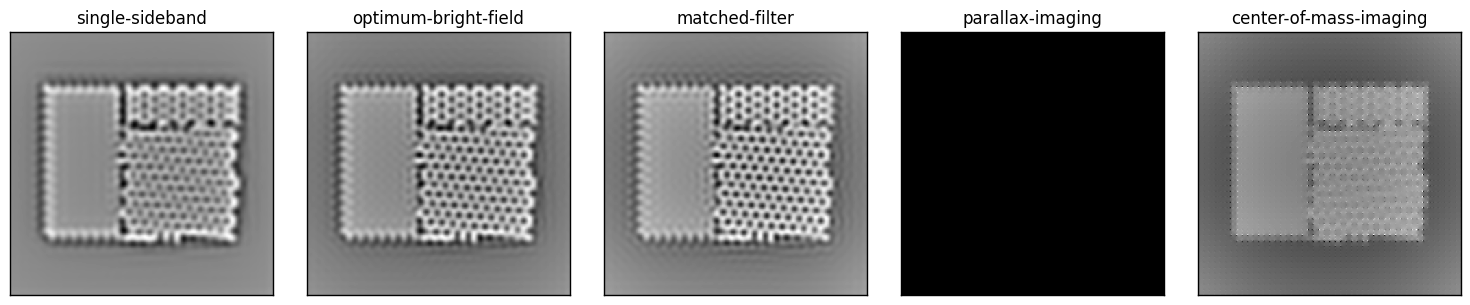

In [28]:
kwargs = {
    "title":["single-sideband","optimum-bright-field","matched-filter","parallax-imaging","center-of-mass-imaging"],
    "norm":"minmax",
    "axsize":(3,3),
}
# in-focus, high dose
recons = direct_ptychography_classes[0]._reconstruct_all_permutations(upsampling_factor=8)
recons_tiled = [np.tile(recon,(1,1)) for recon in recons]

em.visualization.show_2d(
    recons_tiled,
    **kwargs
);

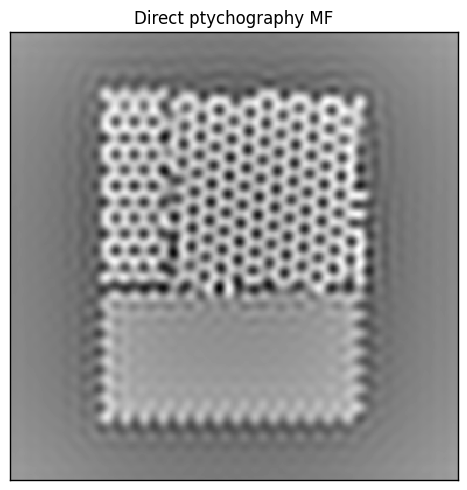

In [29]:
kwargs = {
    "title":['Direct ptychography MF'],
    "norm":"minmax",
    "axsize":(5,5),
}
em.visualization.show_2d(
    np.rot90(recons_tiled[2],k=1),
    **kwargs,
);

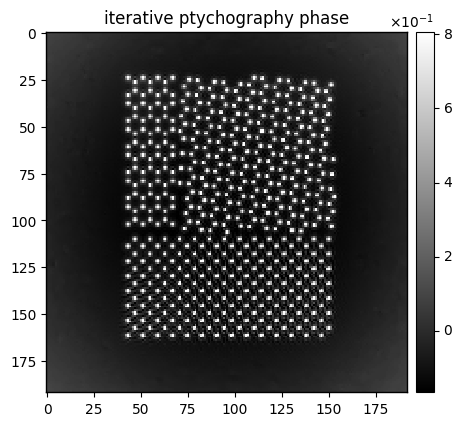

In [30]:
em.visualization.show_2d(
    [
        [
            np.rot90(np.angle(iterative_ptycho.obj[0]),k=1),
        ],
    ],
    title=[
        ["iterative ptychography phase"],
    ],
    axsize=(5,5),
    cbar=True,
    show_ticks=True
);

